In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set up visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# 1. Dataset Description

## Comprehensive Dataset Documentation
This section provides detailed information about the dataset used in our retail analytics project, covering its origin, characteristics, and analytical suitability.

**Source**: 
- Kaggle - Online Retail for Market Basket Analysis
- Originally from UCI Machine Learning Repository
- Real-world transactional data from UK-based online retail
- Publicly available benchmark dataset for retail analytics

**Description**: 
- Contains 541,909 transactional records from December 2010 to December 2011
- Includes 8 attributes: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country
- Represents both retail and wholesale customer transactions
- Features international sales with primary focus on UK market
- Contains actual business data with realistic operational challenges

**Why we are using them**:
- Ideal for market basket analysis and association rule mining
- Comprehensive customer identification enables behavioral analysis
- Complete yearly data supports seasonal trend identification
- Rich transactional details facilitate multi-dimensional analysis
- Proven utility in academic research and industry applications
- Enables both descriptive and predictive analytics approaches

In [3]:
# Load the dataset
df = pd.read_csv('../data/Online_Retail.csv')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


# 2. Exploratory Data Analysis

## Comprehensive Data Investigation and Insight Generation
This section presents a thorough exploratory analysis of the retail dataset, employing statistical techniques and visual analytics to uncover patterns, relationships, and business insights. EDA serves as our primary tool for understanding customer behavior, sales dynamics, and operational patterns.

**Analytical Framework:**
- **Descriptive Analytics**: Summary statistics and data distributions
- **Diagnostic Analytics**: Root cause analysis and pattern identification
- **Visual Analytics**: Interactive charts and graphs for intuitive understanding
- **Comparative Analysis**: Performance across dimensions and time periods

**Business Intelligence Deliverables:**
- Customer segmentation and profiling insights
- Sales performance trends and seasonal patterns
- Product association and market basket revelations
- Operational efficiency indicators and metrics
- Actionable recommendations based on data evidence

**Methodological Approach:**
- Systematic examination of all dataset dimensions
- Hypothesis-driven investigation of business questions
- Multi-perspective analysis (customer, product, temporal, geographical)
- Validation of findings through multiple analytical techniques

In [4]:
# Basic dataset information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (541909, 8)

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Dataset Information and Basic Statistics
This section provides detailed information about the dataset including data types, memory usage, and basic statistical summaries of numerical columns.

In [5]:
# Dataset info and basic statistics
print("Dataset Information:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

Basic Statistics:
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.00

### Missing Values Analysis
Identifying missing values is crucial for data quality assessment. This analysis helps us understand which columns have missing data and to what extent.

In [6]:
# Check for missing values
print("Missing Values:")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
print(missing_info)

Missing Values:
             Missing Count  Missing Percentage
InvoiceNo                0            0.000000
StockCode                0            0.000000
Description           1454            0.268311
Quantity                 0            0.000000
InvoiceDate              0            0.000000
UnitPrice                0            0.000000
CustomerID          135080           24.926694
Country                  0            0.000000


### Data Types and Structure
Understanding the data types of each column helps ensure we handle the data appropriately during analysis and processing.

In [7]:
# Check data types
print("Data Types:")
print(df.dtypes)

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


### Duplicate Records Check
Duplicate records can skew our analysis results. This check helps identify and understand the extent of duplication in the dataset.

In [8]:
# Check for duplicate entries
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5268


### Unique Values Analysis
Understanding the cardinality of key columns helps us understand the scale of our business in terms of customers, products, and transactions.

In [9]:
# Check unique values in key columns
print("Unique values in key columns:")
print("Number of unique invoices:", df['InvoiceNo'].nunique())
print("Number of unique products:", df['StockCode'].nunique())
print("Number of unique customers:", df['CustomerID'].nunique())
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

Unique values in key columns:
Number of unique invoices: 25900
Number of unique products: 4070
Number of unique customers: 4372
Date range: 1/10/2011 10:04 to 9/9/2011 9:52


### Data Cleaning Process
In this section, we systematically clean the data by handling missing values, removing invalid records, and addressing data quality issues to prepare the dataset for analysis.

In [10]:
# Create a copy for cleaning
df_clean = df.copy()

# Display initial shape
print("Original dataset shape:", df_clean.shape)

Original dataset shape: (541909, 8)


### Handling Missing Values
We address missing values by:
- Removing rows with missing CustomerID (essential for customer analysis)
- Filling missing product descriptions with 'Unknown' to preserve records

In [11]:
# Handle missing values
print("Before handling missing values:")
print(df_clean.isnull().sum())

# Remove rows where CustomerID is null (essential for customer analysis)
df_clean = df_clean.dropna(subset=['CustomerID'])

# For Description missing values, we can fill with 'Unknown'
df_clean['Description'] = df_clean['Description'].fillna('Unknown')

print("\nAfter handling missing values:")
print(df_clean.isnull().sum())
print("Dataset shape after cleaning:", df_clean.shape)

Before handling missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

After handling missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
Dataset shape after cleaning: (406829, 8)


### Removing Cancelled Orders
Cancelled orders (identified by InvoiceNo starting with 'C') are removed from our analysis as they don't represent actual sales and could distort our revenue calculations.

In [12]:
# Remove cancelled orders (InvoiceNo starting with 'C')
cancelled_orders = df_clean[df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print("Number of cancelled orders:", len(cancelled_orders))
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print("Dataset shape after removing cancelled orders:", df_clean.shape)

Number of cancelled orders: 8905
Dataset shape after removing cancelled orders: (397924, 8)


### Handling Negative Values
Negative quantities and prices typically represent returns or data errors. We remove these to focus on actual sales transactions.

In [13]:
# Handle negative quantities and prices
print("Rows with negative quantity:", len(df_clean[df_clean['Quantity'] < 0]))
print("Rows with negative unit price:", len(df_clean[df_clean['UnitPrice'] < 0]))

# Remove rows with negative quantity and unit price
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]
print("Dataset shape after removing negative values:", df_clean.shape)

Rows with negative quantity: 0
Rows with negative unit price: 0
Dataset shape after removing negative values: (397884, 8)


### Outlier Detection and Removal
Using the Interquartile Range (IQR) method to identify and remove outliers in Quantity and UnitPrice columns. This helps prevent extreme values from skewing our analysis.

In [14]:
# Remove outliers in Quantity and UnitPrice
Q1_qty = df_clean['Quantity'].quantile(0.25)
Q3_qty = df_clean['Quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty

Q1_price = df_clean['UnitPrice'].quantile(0.25)
Q3_price = df_clean['UnitPrice'].quantile(0.75)
IQR_price = Q3_price - Q1_price

df_clean = df_clean[
    (df_clean['Quantity'] <= Q3_qty + 1.5 * IQR_qty) & 
    (df_clean['UnitPrice'] <= Q3_price + 1.5 * IQR_price)
]
print("Dataset shape after removing outliers:", df_clean.shape)

Dataset shape after removing outliers: (338151, 8)


### Creating New Features
We enhance the dataset by creating new features that will provide deeper insights:
- TotalAmount: Revenue per transaction line
- Temporal features: Year, Month, Day, Weekday, Hour for time-based analysis

In [15]:
# Create new features
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Day'] = df_clean['InvoiceDate'].dt.day
df_clean['Weekday'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

print("New features created:")
print(df_clean[['InvoiceDate', 'Year', 'Month', 'Day', 'Weekday', 'Hour', 'TotalAmount']].head())

New features created:
          InvoiceDate  Year  Month  Day    Weekday  Hour  TotalAmount
0 2010-12-01 08:26:00  2010     12    1  Wednesday     8        15.30
1 2010-12-01 08:26:00  2010     12    1  Wednesday     8        20.34
2 2010-12-01 08:26:00  2010     12    1  Wednesday     8        22.00
3 2010-12-01 08:26:00  2010     12    1  Wednesday     8        20.34
4 2010-12-01 08:26:00  2010     12    1  Wednesday     8        20.34


### Summary Statistics After Cleaning
This section provides an overview of the cleaned dataset including key business metrics like total revenue, average transaction value, and customer/product counts.

In [16]:
print("Cleaned Dataset Overview:")
print(f"Shape: {df_clean.shape}")
print(f"Time period: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"Total revenue: £{df_clean['TotalAmount'].sum():,.2f}")
print(f"Average transaction value: £{df_clean['TotalAmount'].mean():.2f}")
print(f"Total number of transactions: {df_clean['InvoiceNo'].nunique()}")
print(f"Total number of customers: {df_clean['CustomerID'].nunique()}")
print(f"Total number of products: {df_clean['StockCode'].nunique()}")

Cleaned Dataset Overview:
Shape: (338151, 14)
Time period: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Total revenue: £4,318,862.52
Average transaction value: £12.77
Total number of transactions: 16826
Total number of customers: 4191
Total number of products: 3392


### Monthly Sales Trend Analysis
Visualizing the monthly sales trend helps identify seasonal patterns, growth trends, and potential anomalies in the business performance over time.

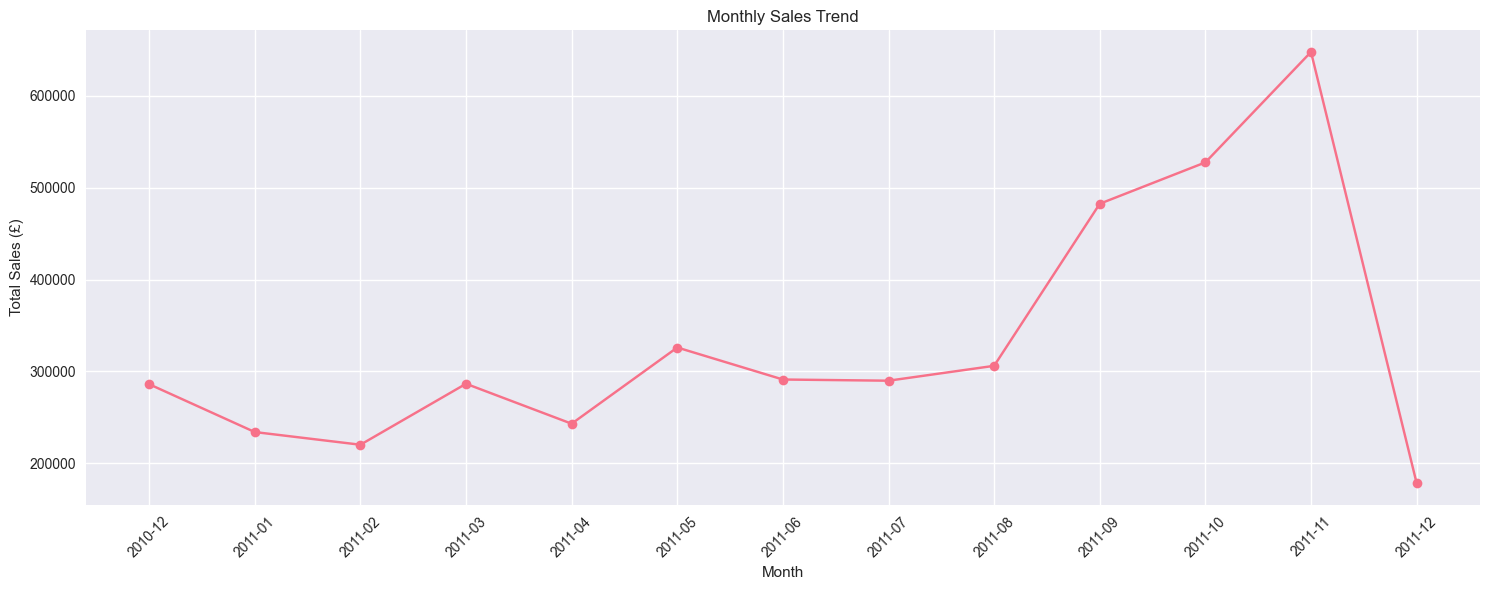

In [17]:
# Monthly sales trend
monthly_sales = df_clean.groupby(['Year', 'Month'])['TotalAmount'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(15, 6))
plt.plot(monthly_sales['YearMonth'], monthly_sales['TotalAmount'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (£)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Top Customers Analysis
Identifying the top customers by spending helps understand customer value and can inform loyalty programs and targeted marketing strategies.

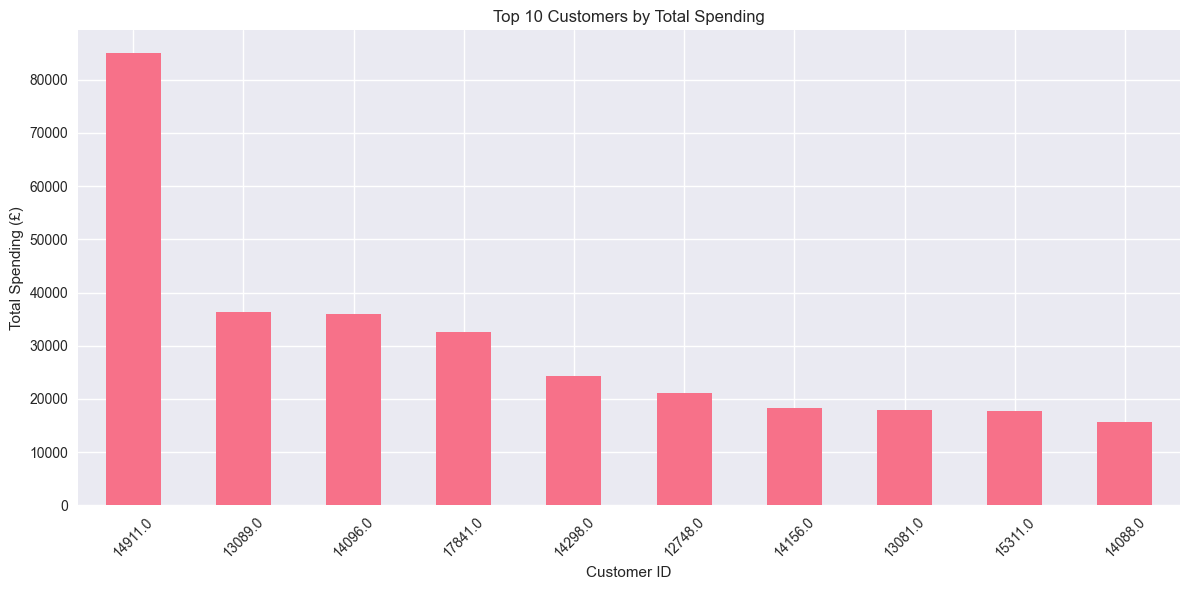

In [18]:
# Top customers by spending
top_customers = df_clean.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_customers.plot(kind='bar')
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spending (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Customer Spending Distribution
Understanding the distribution of customer spending helps identify different customer segments and the overall health of the customer base.

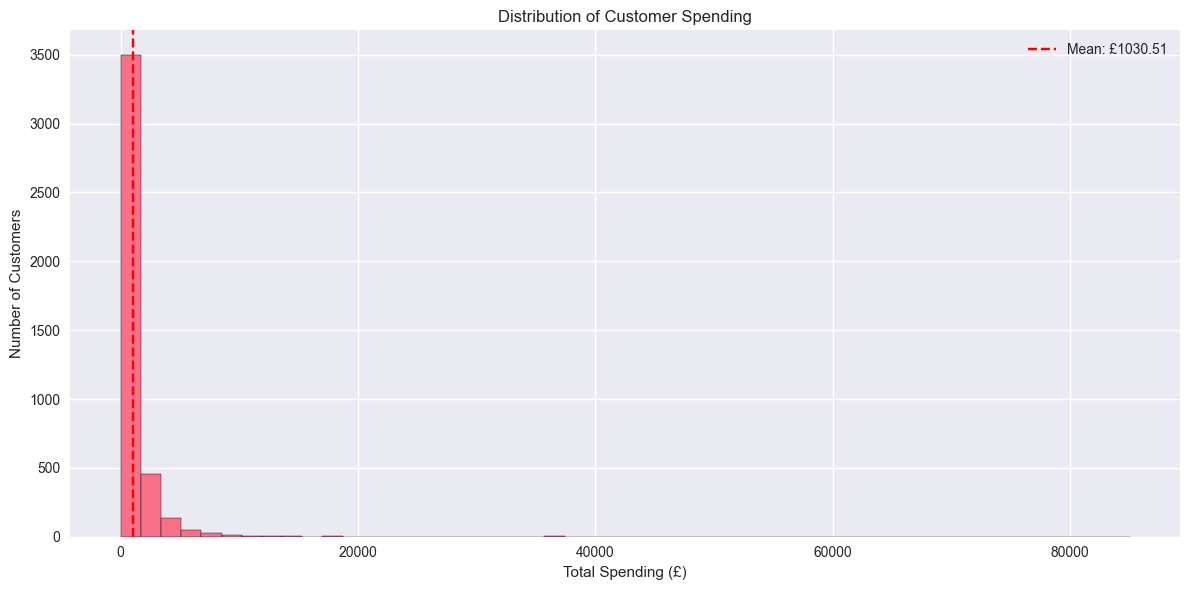

In [19]:
# Customer distribution by spending
customer_spending = df_clean.groupby('CustomerID')['TotalAmount'].sum()

plt.figure(figsize=(12, 6))
plt.hist(customer_spending, bins=50, edgecolor='black')
plt.title('Distribution of Customer Spending')
plt.xlabel('Total Spending (£)')
plt.ylabel('Number of Customers')
plt.axvline(customer_spending.mean(), color='red', linestyle='--', label=f'Mean: £{customer_spending.mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

### Top Products by Quantity Sold
Identifying the most popular products by quantity sold helps understand product demand and inventory planning requirements.

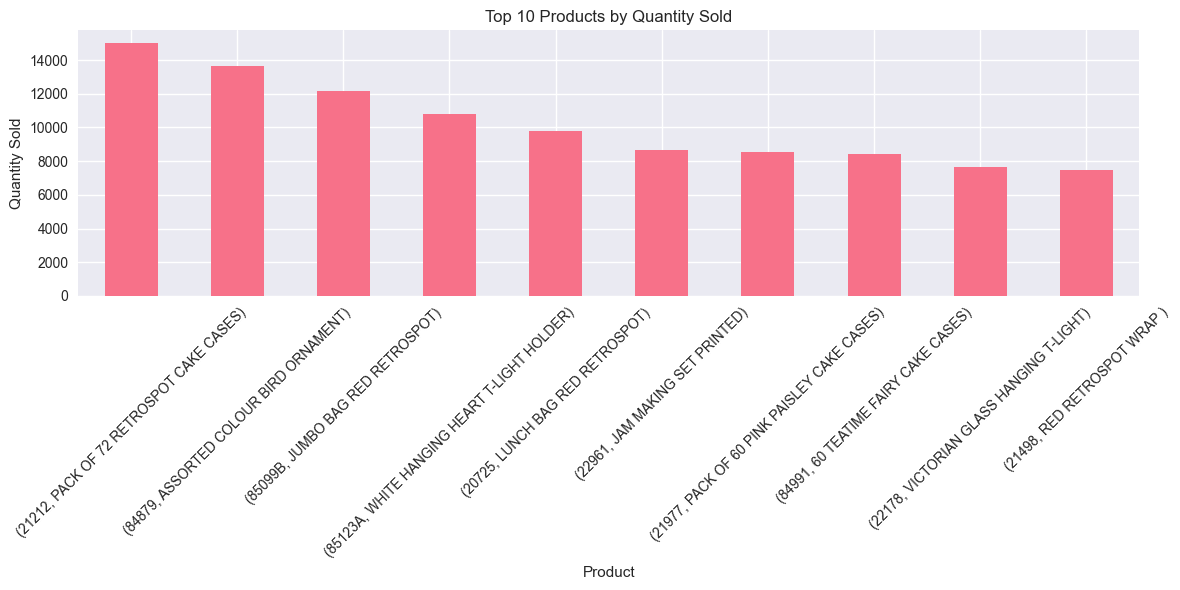

In [20]:
# Top products by quantity sold
top_products_qty = df_clean.groupby(['StockCode', 'Description'])['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_products_qty.plot(kind='bar')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Top Products by Revenue
Analyzing products by revenue generation helps identify the most valuable products and informs pricing and promotion strategies.

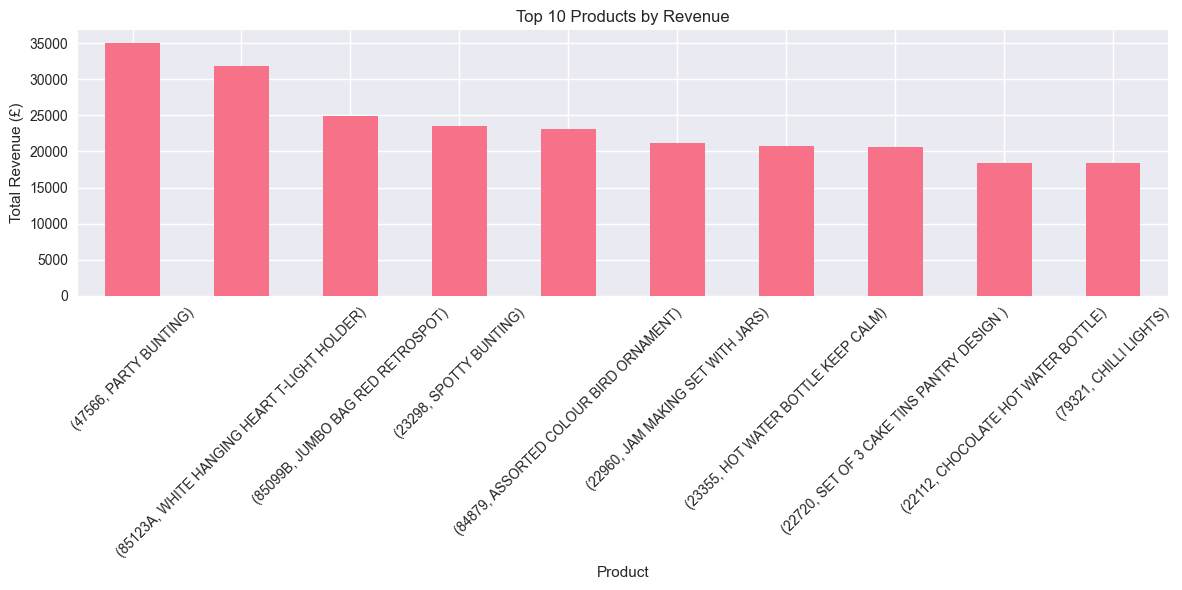

In [21]:
# Top products by revenue
top_products_revenue = df_clean.groupby(['StockCode', 'Description'])['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_products_revenue.plot(kind='bar')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sales Distribution by Weekday
Understanding weekly sales patterns helps in staff scheduling, inventory management, and identifying peak business days.

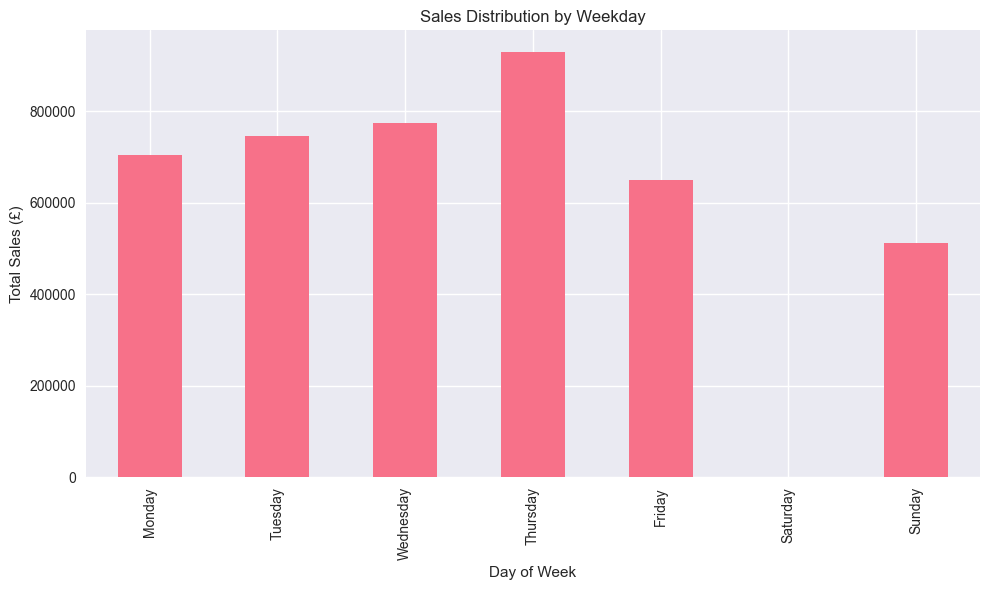

In [22]:
# Sales by weekday
weekday_sales = df_clean.groupby('Weekday')['TotalAmount'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

plt.figure(figsize=(10, 6))
weekday_sales.plot(kind='bar')
plt.title('Sales Distribution by Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales (£)')
plt.tight_layout()
plt.show()

### Sales Distribution by Hour
Analyzing hourly sales patterns helps understand customer shopping behavior throughout the day and optimize operational hours.

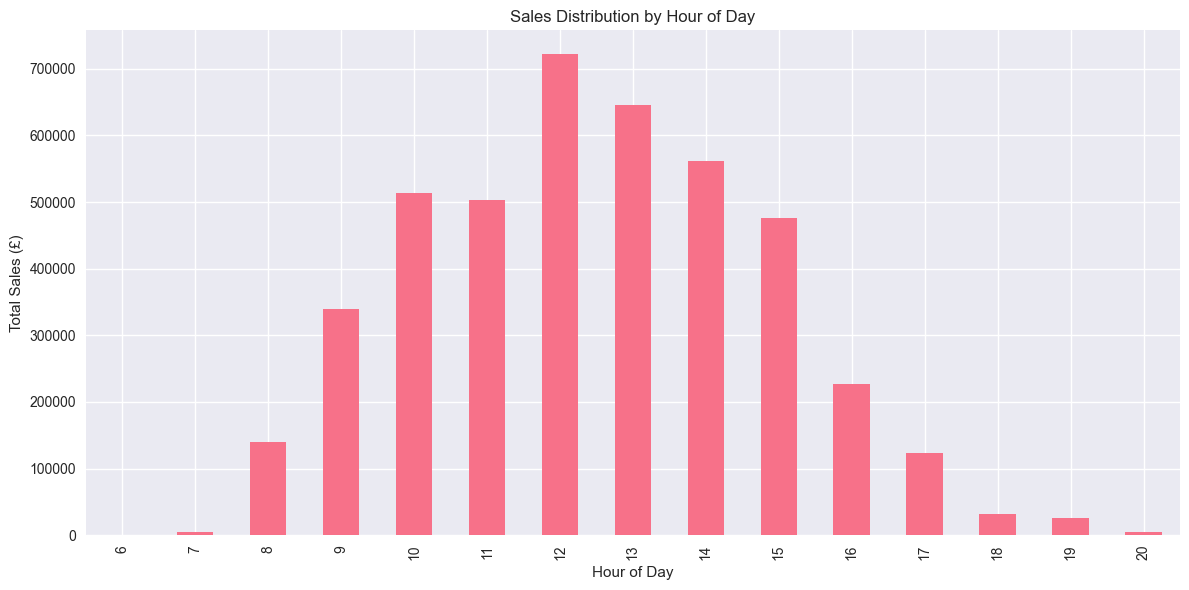

In [23]:
# Sales by hour
hourly_sales = df_clean.groupby('Hour')['TotalAmount'].sum()

plt.figure(figsize=(12, 6))
hourly_sales.plot(kind='bar')
plt.title('Sales Distribution by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales (£)')
plt.tight_layout()
plt.show()

### Geographic Sales Analysis
Understanding sales distribution across countries helps identify key markets and inform international business strategies.

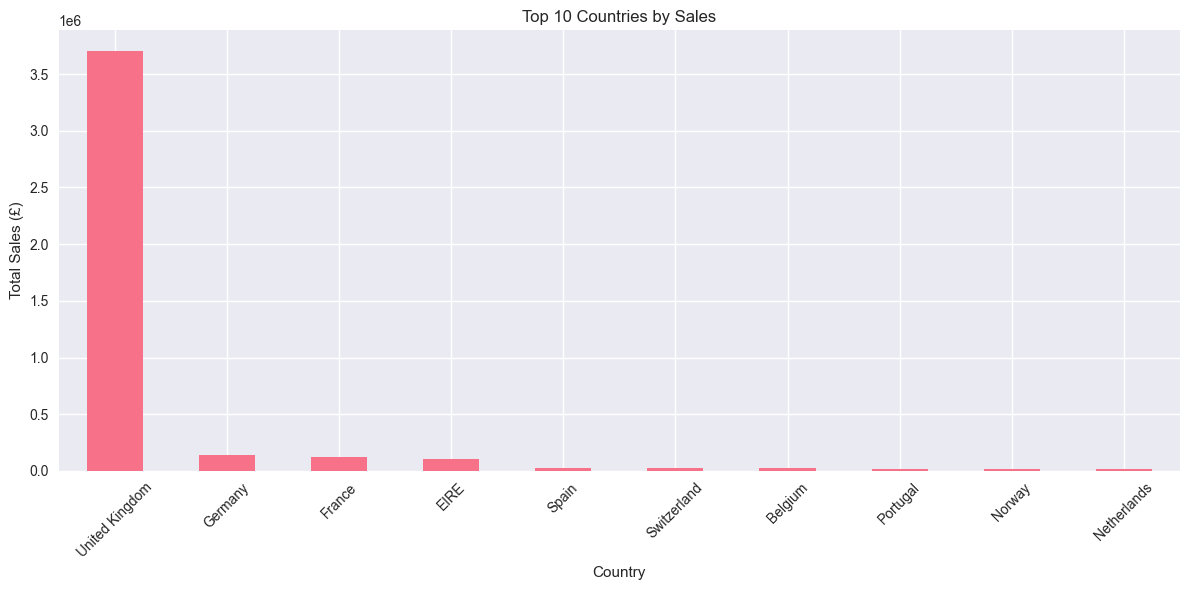

In [24]:
# Sales by country
country_sales = df_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
country_sales.plot(kind='bar')
plt.title('Top 10 Countries by Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Matrix
The correlation matrix helps identify relationships between numerical variables, which can inform feature selection for predictive modeling.

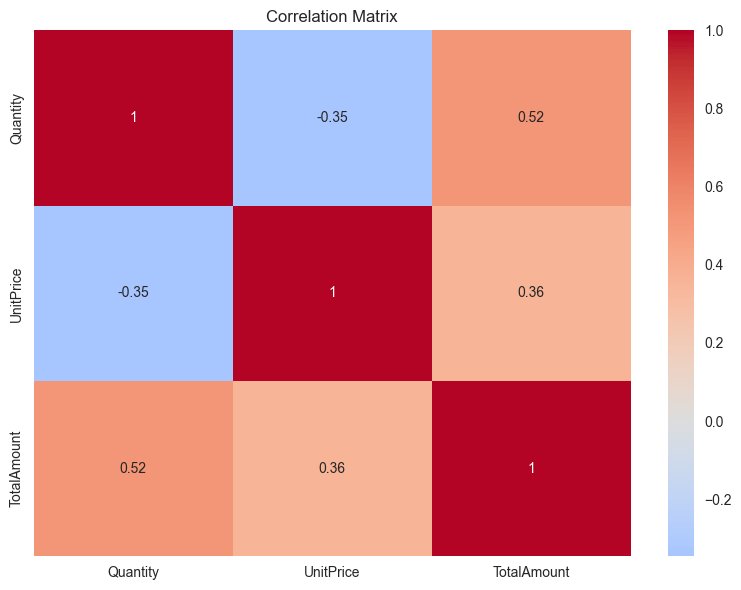

In [25]:
# Select numerical columns for correlation
numerical_cols = ['Quantity', 'UnitPrice', 'TotalAmount']
correlation_matrix = df_clean[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Key Business Insights
This section summarizes the most important findings from our analysis, providing actionable insights for business decision-making.

In [26]:
# Summary statistics
print("KEY INSIGHTS AND SUMMARY")
print("="*50)

# Basic metrics
total_revenue = df_clean['TotalAmount'].sum()
avg_transaction_value = df_clean.groupby('InvoiceNo')['TotalAmount'].sum().mean()
avg_items_per_transaction = df_clean.groupby('InvoiceNo')['Quantity'].sum().mean()

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Average Transaction Value: £{avg_transaction_value:.2f}")
print(f"Average Items per Transaction: {avg_items_per_transaction:.1f}")
print(f"Total Customers: {df_clean['CustomerID'].nunique()}")
print(f"Total Products: {df_clean['StockCode'].nunique()}")
print(f"Total Transactions: {df_clean['InvoiceNo'].nunique()}")

# Top performing metrics
top_product = df_clean.groupby('Description')['TotalAmount'].sum().idxmax()
top_country = df_clean.groupby('Country')['TotalAmount'].sum().idxmax()
best_month = monthly_sales.loc[monthly_sales['TotalAmount'].idxmax(), 'YearMonth']

print(f"\nTop Performing Product: {top_product}")
print(f"Top Country by Sales: {top_country}")
print(f"Best Sales Month: {best_month}")

# Customer value metrics
customer_lifetime_value = df_clean.groupby('CustomerID')['TotalAmount'].sum()
print(f"\nAverage Customer Lifetime Value: £{customer_lifetime_value.mean():.2f}")
print(f"Top Customer Spent: £{customer_lifetime_value.max():.2f}")

KEY INSIGHTS AND SUMMARY
Total Revenue: £4,318,862.52
Average Transaction Value: £256.68
Average Items per Transaction: 150.3
Total Customers: 4191
Total Products: 3392
Total Transactions: 16826

Top Performing Product: PARTY BUNTING
Top Country by Sales: United Kingdom
Best Sales Month: 2011-11

Average Customer Lifetime Value: £1030.51
Top Customer Spent: £85018.78


### Data Pre-processing Summary

This section provides a comprehensive overview of all data cleaning steps performed, showing the impact of each step on the dataset size and quality. Data pre-processing is a critical phase that ensures the reliability and accuracy of our analysis by addressing data quality issues and preparing the dataset for modeling.

**Pre-processing Pipeline:**
- Handling missing values and incomplete records
- Removing invalid transactions and data errors
- Addressing outliers and anomalous values
- Standardizing data formats and types
- Creating derived features for enhanced analysis

**Quality Assurance Metrics:**
- Track data retention rates after each cleaning step
- Monitor impact on key business metrics
- Validate data consistency and integrity
- Ensure compliance with analysis requirements
- Document all transformations for reproducibility

**Business Impact:**
- Improved model accuracy and reliability
- More accurate business insights and recommendations
- Reduced bias from data quality issues
- Enhanced decision-making capabilities
- Foundation for robust predictive modeling

In [29]:
print("DATA PRE-PROCESSING SUMMARY")
print("="*40)
print(f"Original dataset size: {df.shape}")
print(f"Final cleaned dataset size: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")
print(f"Percentage of data retained: {(df_clean.shape[0] / df.shape[0]) * 100:.2f}%")

print("\nData Cleaning Steps Applied:")
print("1. Removed rows with missing CustomerID")
print("2. Filled missing Description with 'Unknown'")
print("3. Removed cancelled orders (InvoiceNo starting with 'C')")
print("4. Removed negative quantities and unit prices")
print("5. Removed outliers using IQR method")
print("6. Created new features: TotalAmount, temporal features")

DATA PRE-PROCESSING SUMMARY
Original dataset size: (541909, 8)
Final cleaned dataset size: (338151, 14)
Rows removed: 203758
Percentage of data retained: 62.40%

Data Cleaning Steps Applied:
1. Removed rows with missing CustomerID
2. Filled missing Description with 'Unknown'
3. Removed cancelled orders (InvoiceNo starting with 'C')
4. Removed negative quantities and unit prices
5. Removed outliers using IQR method
6. Created new features: TotalAmount, temporal features


# 4. Feature Engineering

## Strategic Variable Creation for Enhanced Analytics
This section details the creation of derived variables and analytical features that extend the analytical capabilities beyond raw data. Feature engineering transforms basic transactional data into powerful predictors and segmentation variables for advanced modeling.

**Engineering Categories:**
- **Temporal Features**: Date-based variables for time series analysis
- **Behavioral Features**: Customer interaction and engagement metrics
- **Monetary Features**: Revenue, profitability, and value indicators
- **Product Features**: Categorization and attribute enhancements
- **Composite Features**: Multi-dimensional business KPIs

**Strategic Objectives:**
- Enable customer lifetime value calculation
- Support RFM (Recency, Frequency, Monetary) segmentation
- Facilitate time-based pattern recognition
- Enhance predictive modeling capabilities
- Support multi-dimensional business analysis

**Value Creation:**
- Transformation of raw transactions into business intelligence
- Creation of modeling-ready analytical dataset
- Enablement of advanced machine learning applications
- Support for strategic business decision-making
- Foundation for personalized marketing and recommendations

# 5. Future Implementation Plan

## Strategic Roadmap for Advanced Analytics Deployment
This section outlines the comprehensive strategy for leveraging the cleaned and feature-enhanced dataset in subsequent project phases. We present a structured approach for advanced analytics implementation and business value realization.

**Advanced Analytical Applications:**

### Market Basket Analysis & Recommendation Engine
- Implementation of Apriori algorithm for association rule mining
- Development of real-time product recommendation system
- Cross-selling and up-selling strategy optimization
- Store layout and product placement recommendations

### Customer Analytics & Segmentation
- RFM-based customer segmentation and profiling
- Customer lifetime value prediction modeling
- Churn prediction and retention strategy development
- Personalized marketing campaign design

### Predictive Modeling & Forecasting
- Sales forecasting using time series analysis
- Demand prediction for inventory optimization
- Customer behavior prediction models
- Price elasticity and promotion impact analysis

### Business Intelligence & Decision Support
- Interactive dashboard development for key metrics
- Real-time sales monitoring and alert systems
- Performance benchmarking and KPI tracking
- Strategic planning support systems

**Implementation Timeline:**
- Phase 1: Prototype development and validation
- Phase 2: Model refinement and business integration
- Phase 3: Scalable deployment and automation
- Phase 4: Continuous improvement and optimization

**Expected Business Outcomes:**
- Data-driven decision-making capabilities
- Enhanced customer experience and engagement
- Optimized operational efficiency
- Increased revenue through targeted interventions
- Sustainable competitive advantage through analytics

### Saving the Cleaned Dataset
The cleaned and processed dataset is saved for future analysis and modeling tasks, ensuring we don't need to repeat the cleaning process.

In [28]:
# Save cleaned dataset for future use
df_clean.to_csv('../data/Online_Retail_Cleaned.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
